# Paper 02 — Blandhol, Bonney, Mogstad & Torgovitsky: *When is TSLS Actually LATE?*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/afrtrivi1120/causal-inference-papers-explainer/blob/master/papers/iv/02-blandhol-bonney-mogstad-torgovitsky-tsls-late/simulation.ipynb)

See this folder's `README.md` for the 12-section explainer. This notebook is its runnable companion.

**What this simulation shows.** When the instrument `Z` is only valid *conditional on* a covariate `X`, the common recipe `ivreg(Y ~ D + X | Z + X)` does *not* recover a complier-mass-weighted average of the stratum LATEs. A saturated estimator (a Wald per stratum, pooled by complier mass) does.

**DGP at a glance.** Two strata `X = 0, 1` with population shares `0.5` each.

| Stratum | `P(Z=1 | X)` | Complier share | Stratum LATE |
|---|---|---|---|
| `X = 0` | 0.15 | 0.20 | 3.0 |
| `X = 1` | 0.55 | 0.60 | 0.0 |

Complier-mass weights: `mass_0 = 0.5 · 0.20 = 0.10`, `mass_1 = 0.5 · 0.60 = 0.30`. Population LATE = `(0.10 · 3.0 + 0.30 · 0.0) / 0.40 = 0.75`.

This is a single-draw illustration at a large `N` so the contrast is sharp without averaging across replications.


## Setup

In [1]:
if (!requireNamespace('AER', quietly = TRUE)) install.packages('AER', quiet = TRUE)

suppressPackageStartupMessages({
  library(tidyverse)
  library(AER)
})
set.seed(20260421)

cat(sprintf('R          %s\n', paste(R.version$major, R.version$minor, sep = '.')))
cat(sprintf('tidyverse  %s\n', packageVersion('tidyverse')))
cat(sprintf('AER        %s\n', packageVersion('AER')))


R          4.5.3


tidyverse  2.0.0


AER        1.2.16


## Parameters and population LATE

In [2]:
N <- 20000   # one draw, large enough that sampling noise is invisible

# Compliance-type mix per stratum (no defiers).
probs_X0 <- c(always = 0.10, never = 0.70, complier = 0.20)
probs_X1 <- c(always = 0.10, never = 0.30, complier = 0.60)

# Asymmetric P(Z=1|X) — symmetric values would mask the weighting bug.
pZ_X0 <- 0.15
pZ_X1 <- 0.55

# Stratum-specific (constant) treatment effects.
tau_X0 <- 3.0
tau_X1 <- 0.0

# Complier-mass-weighted population LATE.
mass_X0 <- 0.5 * probs_X0['complier']
mass_X1 <- 0.5 * probs_X1['complier']
true_LATE <- unname((mass_X0 * tau_X0 + mass_X1 * tau_X1) / (mass_X0 + mass_X1))
cat(sprintf('Population LATE (true): %.3f\n', true_LATE))


Population LATE (true): 0.750


## One draw, two estimators

1. **Unsaturated TSLS** — `ivreg(Y ~ D + X | Z + X)`. The Blandhol et al. recipe-under-fire.
2. **Saturated stratum Wald, pooled by complier mass** — fit a Wald ratio inside each stratum of `X`, then aggregate with weights proportional to estimated complier mass.

In [3]:
X <- rbinom(N, 1, 0.5)
Z <- rbinom(N, 1, ifelse(X == 0, pZ_X0, pZ_X1))

type <- character(N)
type[X == 0] <- sample(c('always','never','complier'), sum(X == 0), replace = TRUE, prob = probs_X0)
type[X == 1] <- sample(c('always','never','complier'), sum(X == 1), replace = TRUE, prob = probs_X1)

D   <- as.integer(type == 'always' | (type == 'complier' & Z == 1))
Y   <- ifelse(D == 1, ifelse(X == 0, tau_X0, tau_X1), 0) + rnorm(N, 0, 1)
df  <- tibble(Y, D, Z, X)

# Estimator 1 — unsaturated TSLS.
fit_unsat <- AER::ivreg(Y ~ D + X | Z + X, data = df)
est_unsat <- unname(coef(fit_unsat)['D'])

# Estimator 2 — Wald per stratum, pooled by estimated complier mass
# (mass_x = (n_x / N) * (P(D=1|Z=1, x) - P(D=1|Z=0, x))).
wald <- function(sub) {
  num <- mean(sub$Y[sub$Z == 1]) - mean(sub$Y[sub$Z == 0])
  den <- mean(sub$D[sub$Z == 1]) - mean(sub$D[sub$Z == 0])
  c(wald = num / den, mass = (nrow(sub) / N) * den)
}
w0 <- wald(filter(df, X == 0))
w1 <- wald(filter(df, X == 1))
est_sat <- unname((w0['mass'] * w0['wald'] + w1['mass'] * w1['wald']) / (w0['mass'] + w1['mass']))

tibble(
  estimator    = c('Truth (population LATE)',
                   'Unsaturated TSLS  (Y ~ D + X | Z + X)',
                   'Saturated stratum Wald (pooled by complier mass)'),
  estimate     = c(true_LATE, est_unsat, est_sat),
  gap_vs_truth = c(0,         est_unsat - true_LATE, est_sat - true_LATE)
)


estimator,estimate,gap_vs_truth
<chr>,<dbl>,<dbl>
Truth (population LATE),0.7500000,0.00000000
Unsaturated TSLS (Y ~ D + X | Z + X),0.5042138,-0.24578624
Saturated stratum Wald (pooled by complier mass),0.8348284,0.08482841


## Diagnostic plot

The two estimates as bars against the true LATE (dashed). Dotted reference lines mark the two stratum LATEs (`tau_X0 = 3.0`, `tau_X1 = 0.0`) — the unsaturated estimate sits between them, with weights that are *not* the complier-mass weights.

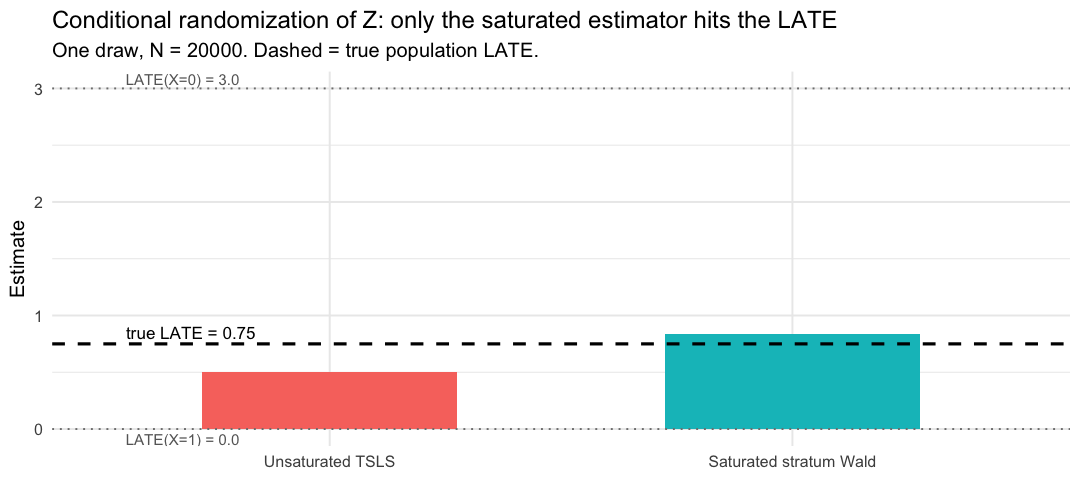

In [4]:
plot_df <- tibble(
  estimator = factor(c('Unsaturated TSLS', 'Saturated stratum Wald'),
                     levels = c('Unsaturated TSLS', 'Saturated stratum Wald')),
  estimate  = c(est_unsat, est_sat)
)

options(repr.plot.width = 9, repr.plot.height = 4)

ggplot(plot_df, aes(estimator, estimate, fill = estimator)) +
  geom_col(width = 0.55) +
  geom_hline(yintercept = true_LATE, linetype = 'dashed', linewidth = 0.9) +
  geom_hline(yintercept = c(tau_X0, tau_X1), linetype = 'dotted', colour = 'grey50') +
  annotate('text', x = 0.55, y = true_LATE, label = ' true LATE = 0.75',
           hjust = 0, vjust = -0.4, size = 3.6) +
  annotate('text', x = 0.55, y = tau_X0, label = ' LATE(X=0) = 3.0',
           hjust = 0, vjust = -0.4, size = 3.2, colour = 'grey40') +
  annotate('text', x = 0.55, y = tau_X1, label = ' LATE(X=1) = 0.0',
           hjust = 0, vjust =  1.4, size = 3.2, colour = 'grey40') +
  labs(title    = 'Conditional randomization of Z: only the saturated estimator hits the LATE',
       subtitle = sprintf('One draw, N = %d. Dashed = true population LATE.', N),
       x = NULL, y = 'Estimate') +
  theme_minimal(base_size = 12) +
  theme(legend.position = 'none')


## Punchline

When `Z` is only valid *conditional on* `X`, you cannot rescue the LATE by adding `X` linearly to the TSLS. The unsaturated specification mixes the stratum LATEs with weights that depend on `Var(Z|X)`, not on complier mass — and those weights can be far from the LATE you want.

This is one draw at `N = 20000`. The paper's claim is in expectation; one draw at this `N` is enough that the sampling noise around each estimate is small, and the contrast you see is the population-level weighting bug, not luck.
